In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ipl=pd.read_csv(r"C:\Users\Tanmay\OneDrive\Desktop\ipl_2026_matches-selected-columns.csv")
ipl

,match_no,date,team1,team2,venue,city,winner,win_by,win_margin,toss_winner
0,1,2026-03-28,Royal Challengers Bengaluru,Sunrisers Hyderabad,M. Chinnaswamy Stadium,Bengaluru,Royal Challengers Bengaluru,wickets,2,Royal Challengers Bengaluru
1,2,2026-03-29,Mumbai Indians,Kolkata Knight Riders,Wankhede Stadium,Mumbai,Kolkata Knight Riders,wickets,4,Mumbai Indians
2,3,2026-03-30,Chennai Super Kings,Rajasthan Royals,M. A. Chidambaram Stadium,Chennai,Rajasthan Royals,wickets,8,Rajasthan Royals
3,4,2026-03-31,Gujarat Titans,Punjab Kings,Narendra Modi Stadium,Ahmedabad,Punjab Kings,wickets,3,Punjab Kings
4,5,2026-04-01,Delhi Capitals,Lucknow Super Giants,Arun Jaitley Stadium,Delhi,Delhi Capitals,wickets,6,Delhi Capitals
...,...,...,...,...,...,...,...,...,...,...
69,70,2026-06-04,Rajasthan Royals,Sunrisers Hyderabad,Sawai Mansingh Stadium,Jaipur,Sunrisers Hyderabad,wickets,5,Sunrisers Hyderabad
70,71,2026-05-26,Royal Challengers Bengaluru,Gujarat Titans,HPCA Cricket Stadium,Dharamshala,Royal Challengers Bengaluru,wickets,5,Gujarat Titans
71,72,2026-05-27,Sunrisers Hyderabad,Rajasthan Royals,Maharaja Yadavindra Singh Stadium,Mullanpur,Rajasthan Royals,wickets,4,Sunrisers Hyderabad
72,73,2026-05-29,Rajasthan Royals,Gujarat Titans,Maharaja Yadavindra Singh Stadium,Mullanpur,Gujarat Titans,wickets,3,Rajasthan Royals


In [49]:
ipl.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   match_no     74 non-null     int64         
 1   date         74 non-null     datetime64[us]
 2   team1        74 non-null     str           
 3   team2        74 non-null     str           
 4   venue        74 non-null     str           
 5   city         74 non-null     str           
 6   winner       74 non-null     str           
 7   win_by       73 non-null     str           
 8   win_margin   74 non-null     int64         
 9   toss_winner  73 non-null     str           
dtypes: datetime64[us](1), int64(2), str(7)
memory usage: 5.9 KB


## Data Cleaning

In [46]:
#Check for missing values in the dataset.
ipl.isnull().sum()

match_no       0
date           0
team1          0
team2          0
venue          0
city           0
winner         0
win_by         1
win_margin     0
toss_winner    1
dtype: int64

In [47]:
#Check for duplicate records and remove them if found.
ipl.duplicated().sum()

np.int64(0)

In [48]:
#Convert the date column into datetime format.
ipl["date"] = pd.to_datetime(ipl["date"])

## Exploratory Data Analysis

In [51]:
#How many matches were played in the tournament?
print(ipl["match_no"].count())

74


In [62]:
#Which teams participated in the tournament?
teams = pd.concat([ipl["team1"],ipl["team2"]]).unique()
print(teams)

<StringArray>
['Royal Challengers Bengaluru',              'Mumbai Indians',
         'Chennai Super Kings',              'Gujarat Titans',
              'Delhi Capitals',         'Sunrisers Hyderabad',
       'Kolkata Knight Riders',        'Lucknow Super Giants',
            'Rajasthan Royals',                'Punjab Kings']
Length: 10, dtype: str


In [81]:
#Which cities hosted the most matches?
ipl["city"].value_counts().head(1)

city
Ahmedabad    10
Name: count, dtype: int64

In [82]:
#Which venues hosted the most matches?
ipl["venue"].value_counts().head(1)

venue
Narendra Modi Stadium    10
Name: count, dtype: int64

## Team Performance Analysis


In [87]:
#Which team won the most matches?
ipl["winner"].value_counts().head(1)

winner
Royal Challengers Bengaluru    12
Name: count, dtype: int64

In [79]:
#Which team had the highest win percentage?
matches_played = pd.concat([ipl["team1"], ipl["team2"]]).value_counts()
matches_won = ipl["winner"].value_counts()
win_percentage = ((matches_won / matches_played) * 100).round(2)
print(win_percentage.sort_values(ascending=False))

winner
Royal Challengers Bengaluru    70.59
Punjab Kings                   69.23
Sunrisers Hyderabad            61.54
Delhi Capitals                 61.54
Gujarat Titans                 57.89
Rajasthan Royals               55.56
Kolkata Knight Riders          33.33
Mumbai Indians                 30.77
Chennai Super Kings            25.00
Lucknow Super Giants           20.00
Match abandoned                  NaN
Name: count, dtype: float64


In [12]:
#How many matches did each team play?
matches_played = pd.concat([ipl["team1"], ipl["team2"]]).value_counts()
print(matches_played)

Gujarat Titans                 19
Rajasthan Royals               18
Royal Challengers Bengaluru    17
Kolkata Knight Riders          15
Lucknow Super Giants           15
Mumbai Indians                 13
Delhi Capitals                 13
Sunrisers Hyderabad            13
Punjab Kings                   13
Chennai Super Kings            12
Name: count, dtype: int64


In [13]:
#Which team won the most matches by runs?
ipl[ipl["win_by"] == "runs"]["winner"].value_counts().head(1)

winner
Sunrisers Hyderabad    6
Name: count, dtype: int64

In [14]:
#Which team won the most matches by wickets?
ipl[ipl["win_by"] == "wickets"]["winner"].value_counts().head(1)

winner
Royal Challengers Bengaluru    9
Name: count, dtype: int64

## Toss Analysis

In [15]:
#Which team won the most matches ?
ipl["toss_winner"].value_counts().head(1)

toss_winner
Gujarat Titans    12
Name: count, dtype: int64

In [16]:
#How often did the toss winner also win the match?
print((ipl["toss_winner"] == ipl["winner"]).sum())

54


In [80]:
#Does winning the toss appear to provide an advantage?
advantage = ((ipl["toss_winner"] == ipl["winner"]).mean() * 100).round(2)
print("Toss winner won" ,advantage,"% of matches.")

Toss winner won 72.97 % of matches.


## Match Margin Analysis

In [18]:
#What was the biggest victory of the season ?
ipl.loc[ipl["win_margin"].idxmax()]

match_no                              19
date                 2026-04-14 00:00:00
team1                Chennai Super Kings
team2                     Mumbai Indians
venue          M. A. Chidambaram Stadium
city                             Chennai
winner               Chennai Super Kings
win_by                              runs
win_margin                           103
toss_winner          Chennai Super Kings
Name: 18, dtype: object

In [19]:
#What is the average winning margin ?
print(ipl["win_margin"].mean().round(2))

17.99


In [89]:
#Which team recorded the largest winning margin ?
ipl.loc[ipl["win_margin"].idxmax(), "winner"]

'Chennai Super Kings'

## Venue & City Insights

In [22]:
#Which venue produced the most competitive matches (smallest average winning margin)?
venue_margin = ipl.groupby("venue")["win_margin"].mean()
print(venue_margin.sort_values().head(1))

venue
Maharaja Yadavindra Singh Stadium    3.5
Name: win_margin, dtype: float64


## Matplotlib Visualization Tasks

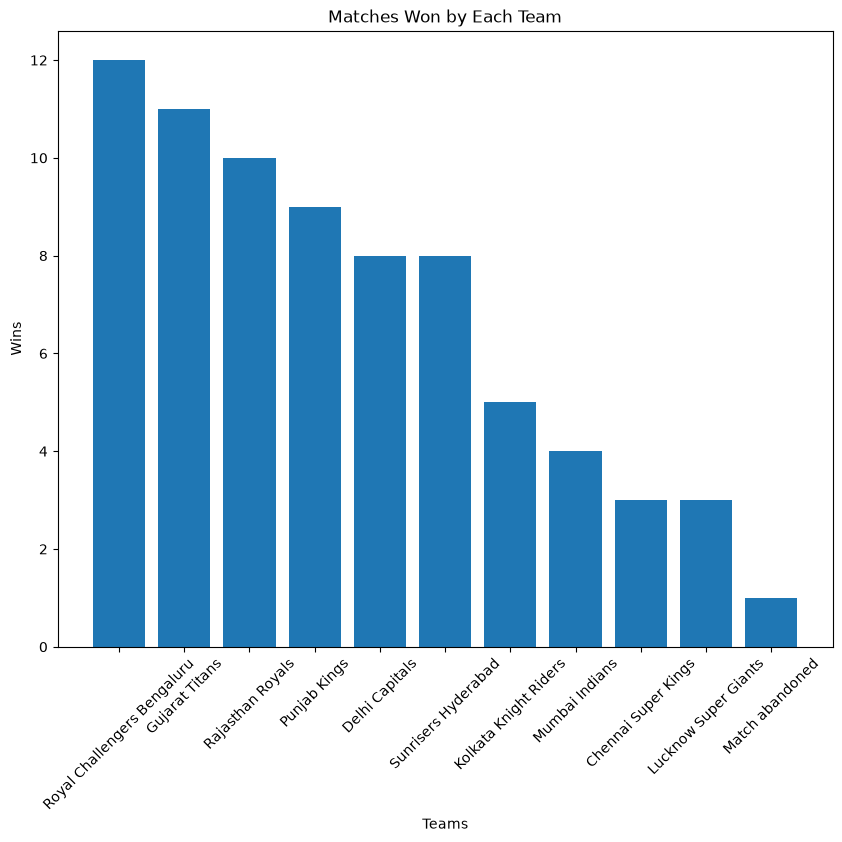

In [37]:
#Create a bar chart showing the number of matches won by each team.
wins = ipl["winner"].value_counts()
plt.figure(figsize=(10,8))
plt.bar(wins.index, wins.values)
plt.title("Matches Won by Each Team")
plt.xlabel("Teams")
plt.ylabel("Wins")
plt.xticks(rotation=45)
plt.show()

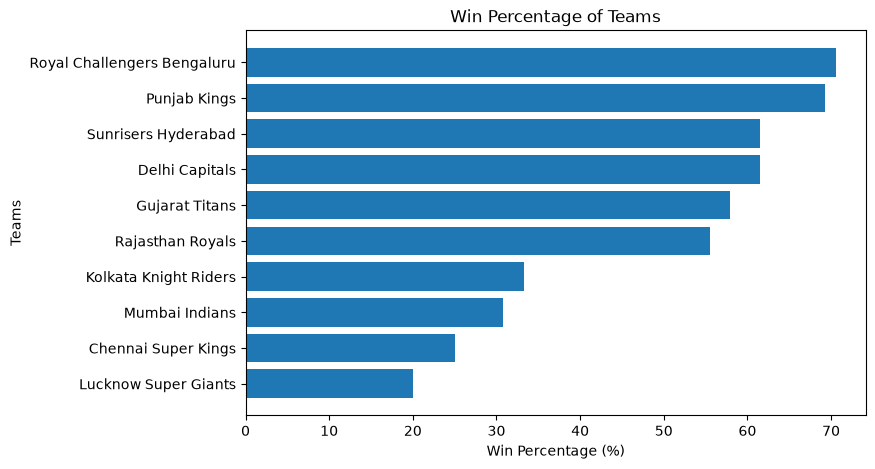

In [26]:
#Create a horizontal bar chart showing the win percentage of every team (highest to lowest).
matches_played = pd.concat([ipl["team1"], ipl["team2"]]).value_counts()
matches_won = ipl["winner"].value_counts()
win_percentage = ((matches_won / matches_played) * 100).round(2)
win_percentage = win_percentage.sort_values()
plt.figure(figsize=(8,5))
plt.barh(win_percentage.index, win_percentage.values)
plt.title("Win Percentage of Teams")
plt.xlabel("Win Percentage (%)")
plt.ylabel("Teams")
plt.show()

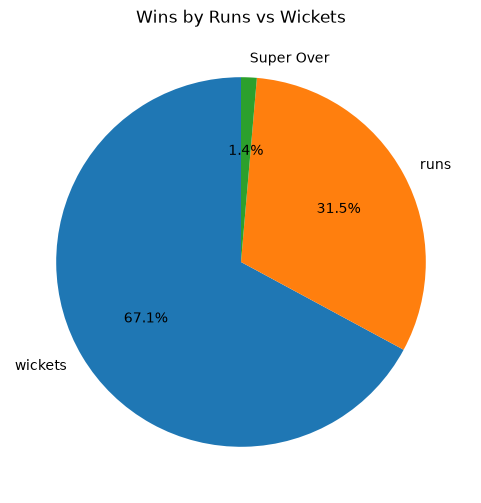

In [27]:
#Create a pie chart showing the distribution of matches won by runs versus wickets.
win_type = ipl["win_by"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
    win_type.values,
    labels=win_type.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Wins by Runs vs Wickets")
plt.show()

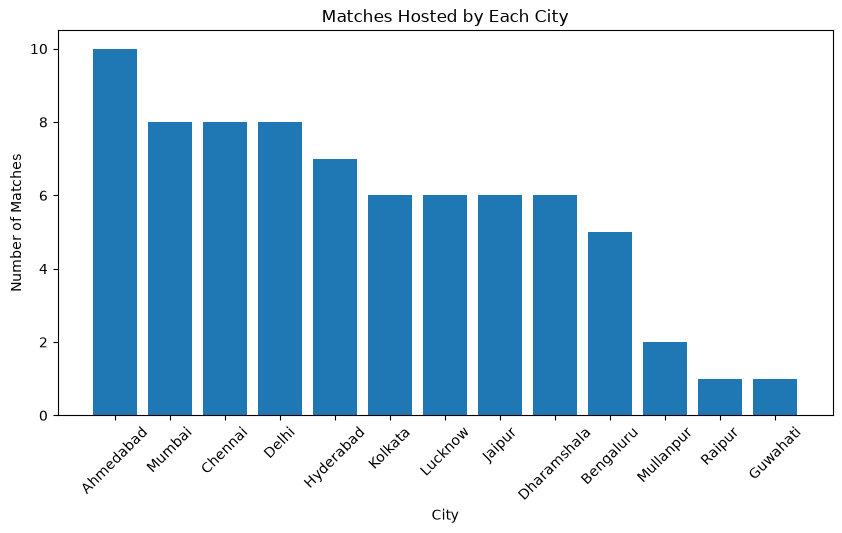

In [28]:
#Create a bar chart showing the number of matches hosted in each city.
city_matches = ipl["city"].value_counts()
plt.figure(figsize=(10,5))
plt.bar(city_matches.index, city_matches.values)
plt.title("Matches Hosted by Each City")
plt.xlabel("City")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.show()

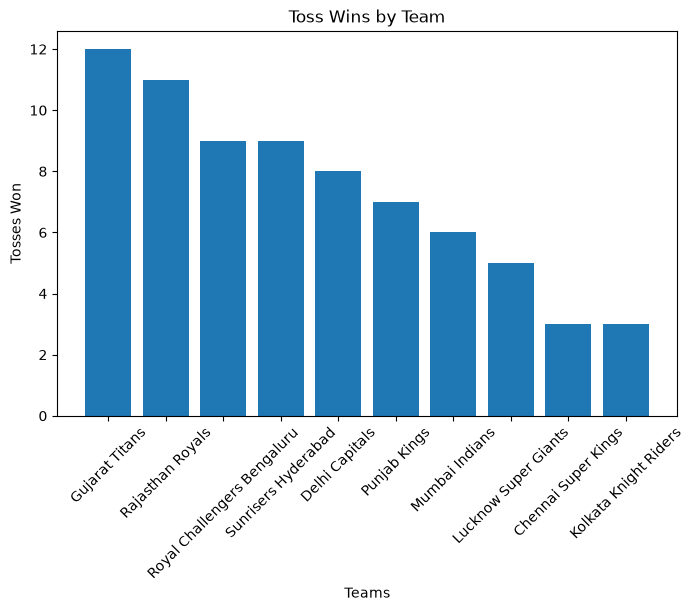

In [41]:
#Create a bar chart showing the number of tosses won by each team.
toss = ipl["toss_winner"].value_counts()
plt.figure(figsize=(8,5))
plt.bar(toss.index, toss.values)
plt.title("Toss Wins by Team")
plt.xlabel("Teams")
plt.ylabel("Tosses Won")
plt.xticks(rotation=45)
plt.show()

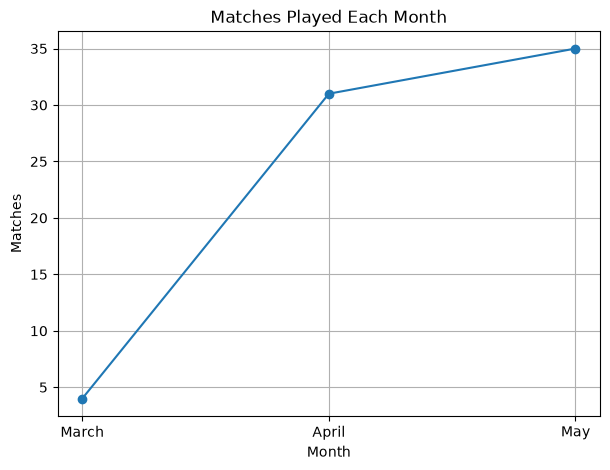

In [30]:
#Create a line graph showing how many matches were played each month (extract the month from the date column).\
ipl["date"] = pd.to_datetime(ipl["date"])
ipl["Month"] = ipl["date"].dt.month_name()
month_order = ["March", "April", "May"]
monthly_matches = (
    ipl.groupby("Month")
    .size()
    .reindex(month_order)
)
plt.figure(figsize=(7,5))
plt.plot(
    monthly_matches.index,
    monthly_matches.values,
    marker="o"
)
plt.title("Matches Played Each Month")
plt.xlabel("Month")
plt.ylabel("Matches")
plt.grid()
plt.show()

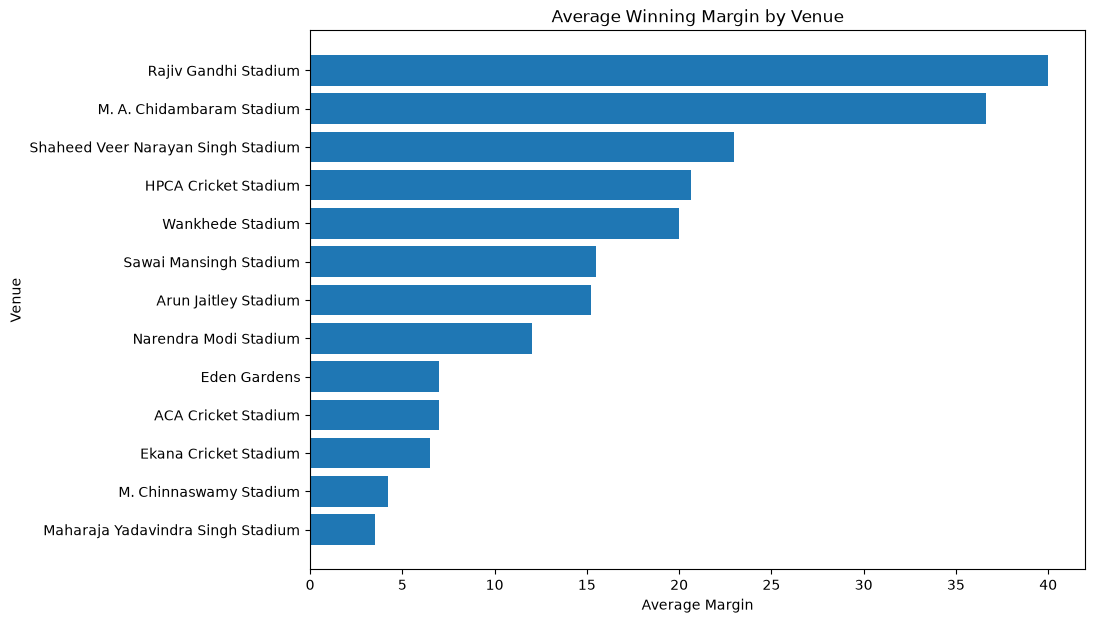

In [31]:
#Create a horizontal bar chart showing the average winning margin at each venue.
venue_margin = (
    ipl.groupby("venue")["win_margin"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(10,7))
plt.barh(
    venue_margin.index,
    venue_margin.values
)
plt.title("Average Winning Margin by Venue")
plt.xlabel("Average Margin")
plt.ylabel("Venue")
plt.show()

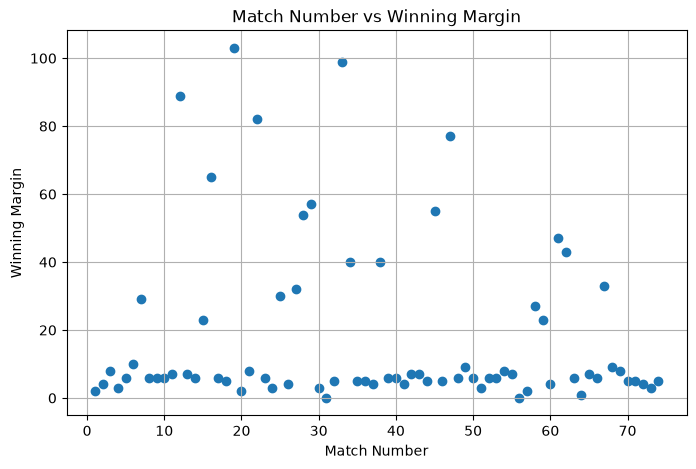

In [32]:
#Create a scatter plot to examine the relationship between match number (match_no) and winning margin (win_margin). Comment on whether any trend exists.
plt.figure(figsize=(8,5))
plt.scatter(
    ipl["match_no"],
    ipl["win_margin"]
)
plt.title("Match Number vs Winning Margin")
plt.xlabel("Match Number")
plt.ylabel("Winning Margin")
plt.grid()
plt.show()